In [1]:
# Load radargrams over David Glacier from KOPRI
# Loads MagLoResInco2 from KPDC which hopefully still has phase info.

from impdar.lib import load, plot 
import os

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
%load_ext autoreload
%autoreload 2

import cartopy.crs as ccrs

import segyio
import shapefile
import shapely
import xarray as xr

In [22]:
path_MagLoResInco = '/mnt/c/users/ZacharyKatz/Desktop/KPDC/KPDC_David_IPR_2017_0028/2016-2017David/pik1/DVG/IBH0c/GL0328c/'
file_paths = [os.path.join(path_MagLoResInco, f) for f in os.listdir(path_MagLoResInco) if f.endswith('MagLoResInco8')]
path = file_paths[0]

In [23]:
raw = np.fromfile(path, dtype="<i2")

samples_per_trace=1024
scale=20000
traces = raw.size // samples_per_trace
data = raw[:traces * samples_per_trace].reshape(traces, samples_per_trace)
data = data.astype(np.float32) / scale


In [24]:
raw = np.fromfile(path, dtype='>i2')   # or >f4 if float32
print(raw[:20])

[     1 -14422      1  -6247      1  -4616      1  -5795      1  -4713
      1  -5401      1  -6892      2   1949      2   5181      2   6270]


In [25]:
data

array([[ 0.0128 , -1.09085,  0.0128 , ..., -1.23235,  0.0128 ,  0.47005],
       [ 0.0128 , -0.77175,  0.0128 , ...,  1.1862 ,  0.0128 , -0.2601 ],
       [ 0.0128 ,  1.00705,  0.0128 , ...,  0.5855 ,  0.0128 , -0.6306 ],
       ...,
       [ 0.0128 , -0.41305,  0.0128 , ..., -1.2705 ,  0.0128 , -1.01475],
       [ 0.0128 ,  0.06005,  0.0128 , ..., -1.30945,  0.0128 , -1.3478 ],
       [ 0.0128 , -0.6182 ,  0.0128 , ...,  0.9435 ,  0.0128 ,  0.85385]],
      shape=(68287, 1024), dtype=float32)

Text(0, 0.5, 'Two-way Travel Time [usec]')

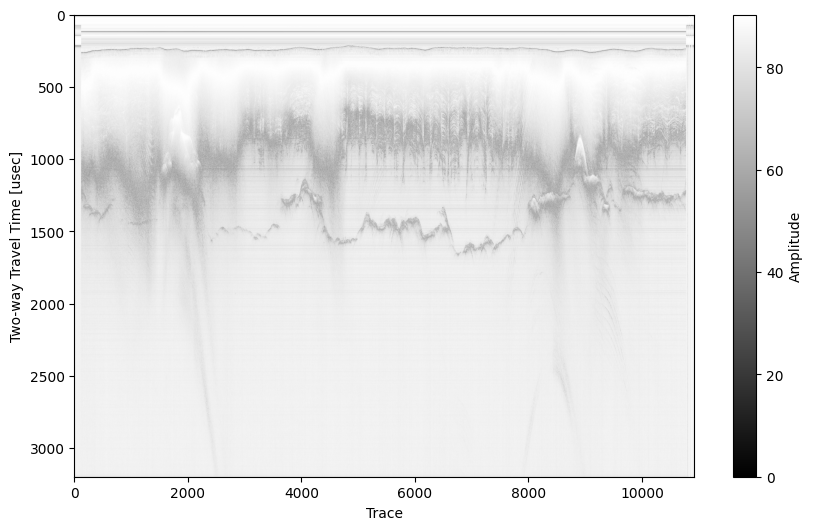

In [26]:
raw = np.fromfile(path, dtype='>i2')

channels = raw[0::2]
amps = raw[1::2]

data = amps.reshape(-1, 3200).astype(float)

radargram = 20*np.log10(np.abs(data) + 1)

fig, ax = plt.subplots(figsize=(10,6))
im = ax.imshow(radargram.T, aspect='auto', cmap='gray')
fig.colorbar(im, ax=ax, label='Amplitude')
ax.set_xlabel('Trace')
ax.set_ylabel('Two-way Travel Time [usec]')